<a href="https://colab.research.google.com/github/aleks-tu/XAI4CV-Projekt/blob/main/CombinationTry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and downloads

In [ ]:
import torch
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import copy
import torch.nn as nn
import torchvision
from torchvision import transforms
import urllib.request

# download vegetable dataset (36 classes) for finetuning
# -> https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition?resource=download
path_dataset_finetuning = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

# Get resnet50 base model

In [ ]:
# Load transformations
# -> https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
weights = models.ResNet50_Weights.IMAGENET1K_V2
transform = weights.transforms()

# Define base model
base_model = models.resnet50(weights=weights)

# Finetune resnet50 with vegetable dataset

In [ ]:
# ----------------------------
# Data Preparation
# ----------------------------

# Define the transformation
# transform = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

# Define a specific image loader to deal with images containing transparent pixels (Make them white)
from PIL import Image
from typing import Union
from pathlib import Path
# def rgba_pil_loader(path: Union[str, Path]) -> Image.Image:
#   # open path as file to avoid ResourceWarning (https://github.com/python-pillow/Pillow/issues/835)

#   # Some images are corrupt
#   corrupt_images_replacement = {
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/bell pepper/Image_56.jpg": "/kaggle/input/fruit-and-vegetable-image-recognition/train/bell pepper/Image_55.jpg",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/potato/Image_69.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/potato/Image_68.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/carrot/Image_68.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/carrot/Image_67.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/soy beans/Image_13.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/soy beans/Image_12.png",
#       "/kaggle/input/fruit-and-vegetable-image-recognition/train/paprika/Image_26.png": "/kaggle/input/fruit-and-vegetable-image-recognition/train/paprika/Image_25.png",
#   }

#   with open(path, "rb") as f:
#       img = Image.open(f)
#       if (img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info)) and len(img.split())>3:
#       #   print("TRANSPARENT!")
#       #   alpha = img.convert("RGBA").split()[-1]
#       #   print("Converted")
#       #   bg = Image.new("RGB", img.size, (255, 255, 255))
#       #   print("made bg")
#       #   bg.paste(img, mask=alpha)
#       #   print("pasted img")
#       #   return bg

#         # print("TRANSPARENT")
#         # img = img.convert("RGBA")
#         # datas = img.getdata()
#         # newData = []
#         # for item in datas:
#         #     if item[0] == 255 and item[1] == 255 and item[2] == 255:
#         #         newData.append((255, 255, 255, 0))
#         #     else:
#         #         newData.append(item)
#         # img.putdata(newData)

#         background = Image.new("RGB", img.size, (255, 255, 255))
#         # print("here")
#         print(f"length: {len(img.split())}")
#         background.paste(img, mask=img.split()[3]) # 3 is the alpha channel

#         # Print value of image at pixel 50, 50:
#         # print(img.getpixel((50, 50)))

#         # print("RETURNING MODIFIED IMG")
#         return img.convert('RGB')
#       elif len(img.split())<3:
#         print("CORRUPT IMAGE -------------------------")
#         print(path)
#         return Image.new("RGB", img.size, (255,255,255))
#       else:
#         # print("NOT TRANSPARENT")
#         return img.convert("RGB")  # Ensure all images are RGB



# # Load the data
# train_data = torchvision.datasets.ImageFolder(root="/kaggle/input/fruit-and-vegetable-image-recognition/train", loader=rgba_pil_loader, transform=transform)
# test_data = torchvision.datasets.ImageFolder(root="/kaggle/input/fruit-and-vegetable-image-recognition/validation", loader=rgba_pil_loader, transform=transform)

# Load the data
train_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/train", transform=transform)
test_data = torchvision.datasets.ImageFolder(root=path_dataset_finetuning+"/validation", transform=transform)

# Define the dataloaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# ----------------------------
# Modify Finetuned Model
# ----------------------------

# Define the model
finetuned_model = copy.deepcopy(base_model)

# # Freeze all parameters:
# for param in finetuned_model.parameters():
#     param.requires_grad = False

# Freeze all layers but the third and fourth (last two) sequential blocks
for name, param in finetuned_model.named_parameters():
  if not ('layer4' in name or 'layer3' in name):
      param.requires_grad = False
  print(f"Training {name}: {param.requires_grad}")

# Replace the last layer
num_features = finetuned_model.fc.in_features
finetuned_model.fc = nn.Linear(num_features, len(train_data.classes))
print("---------------------------------------------")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Different classes: {train_data.classes}")

Training conv1.weight: False
Training bn1.weight: False
Training bn1.bias: False
Training layer1.0.conv1.weight: False
Training layer1.0.bn1.weight: False
Training layer1.0.bn1.bias: False
Training layer1.0.conv2.weight: False
Training layer1.0.bn2.weight: False
Training layer1.0.bn2.bias: False
Training layer1.0.conv3.weight: False
Training layer1.0.bn3.weight: False
Training layer1.0.bn3.bias: False
Training layer1.0.downsample.0.weight: False
Training layer1.0.downsample.1.weight: False
Training layer1.0.downsample.1.bias: False
Training layer1.1.conv1.weight: False
Training layer1.1.bn1.weight: False
Training layer1.1.bn1.bias: False
Training layer1.1.conv2.weight: False
Training layer1.1.bn2.weight: False
Training layer1.1.bn2.bias: False
Training layer1.1.conv3.weight: False
Training layer1.1.bn3.weight: False
Training layer1.1.bn3.bias: False
Training layer1.2.conv1.weight: False
Training layer1.2.bn1.weight: False
Training layer1.2.bn1.bias: False
Training layer1.2.conv2.weight

In [ ]:
"""
# ----------------------------
# Prepare Training
# ----------------------------

# import warnings
# warnings.filterwarnings('ignore', '.*UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images',)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(finetuned_model.parameters(), lr=0.001, momentum=0.9)

# Move the model to the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
finetuned_model = finetuned_model.to(device)

# ----------------------------
# Train
# ----------------------------

# Define the number of epochs
num_epochs = 10

# Train the model
for epoch in range(num_epochs):
    # Train the model on the training set
    finetuned_model.train()
    train_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Move the data to the device
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = finetuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update the training loss
        train_loss += loss.item() * inputs.size(0)

    # Evaluate the model on the test set
    finetuned_model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            # Move the data to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward
            outputs = finetuned_model(inputs)
            loss = criterion(outputs, labels)

            # Update the test loss and accuracy
            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

    # Print the training and test loss and accuracy
    train_loss /= len(train_data)
    test_loss /= len(test_data)
    test_acc = test_acc.double() / len(test_data)
    print(f"Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f} Test Loss: {test_loss:.4f} Test Acc: {test_acc:.4f}")


torch.save(finetuned_model.state_dict(), "fine-tuned-resnet.pt")
"""

'\n# ----------------------------\n# Prepare Training\n# ----------------------------\n\n# import warnings\n# warnings.filterwarnings(\'ignore\', \'.*UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images\',)\n\n# Define the loss function and optimizer\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.SGD(finetuned_model.parameters(), lr=0.001, momentum=0.9)\n\n# Move the model to the device\ndevice = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")\nfinetuned_model = finetuned_model.to(device)\n\n# ----------------------------\n# Train\n# ----------------------------\n\n# Define the number of epochs\nnum_epochs = 10\n\n# Train the model\nfor epoch in range(num_epochs):\n    # Train the model on the training set\n    finetuned_model.train()\n    train_loss = 0.0\n    for i, (inputs, labels) in enumerate(train_loader):\n        # Move the data to the device\n        inputs = inputs.to(device)\n        labels = labels.t

In [ ]:
# Load finetuned model
finetuned_model.load_state_dict(torch.load("/content/drive/MyDrive/fine-tuned-resnet_fruits-vegetables_last_seq_block.pt"))

<All keys matched successfully>

# Test base and finetuned model

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
base_model.to(device)
finetuned_model.to(device)

base_model.eval()
finetuned_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


torch.Size([1, 3, 1200, 1800])


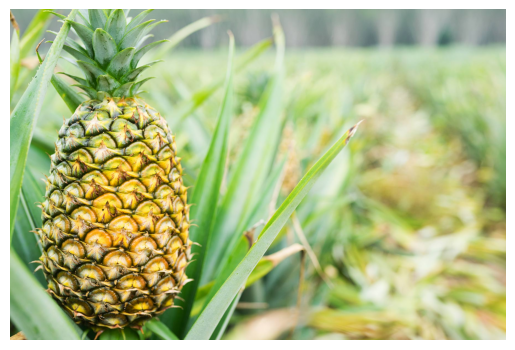

In [ ]:
#img = np.asarray(Image.open('/content/drive/MyDrive/img_dog'))
img = np.asarray(Image.open('/content/drive/MyDrive/pineapple_1.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/pineapple_2.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/apple_1.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/apple_2.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/lemon_1.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/lemon_2.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/carrot_1.jpg'))
#img = np.asarray(Image.open('/content/drive/MyDrive/carrot_2.jpg'))

imgplot = plt.imshow(img)
plt.axis('off')

# to PyTorch/ImageNet (dataset with 1000 classes) format
# The transforms are already set correctly above.
# normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                                   std=[0.229, 0.224, 0.225])
# transform = transforms.Compose([
#                 transforms.ToTensor(),
#                 normalize,
#             ])

img = transform(img) # apply transformation to get the right format for model
img = img.to(device)
img = img.unsqueeze(0) # Shape 1,3,224,224 (Batch,Channel,H,W)
print(img.shape)

In [ ]:
output = base_model(img)
probabilities = torch.nn.functional.softmax(output[0], dim=0)  # output[0] removes batch dimension

top5_probabilites, top5_category_id = torch.topk(probabilities, 5)

# Load ImageNet class labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = urllib.request.urlopen(url).read().decode("utf-8").splitlines()

print("Top 5 predictions of base model:")
for i in range(5):
    class_name = imagenet_classes[top5_category_id[i]]
    prob = top5_probabilites[i].item()
    #print(f"{i+1}. {class_name:20s} -> {prob:.4f}")
    print(f"{class_name} ({top5_category_id[i]})".ljust(20) + f"-> {prob:.4f}")

Top 5 predictions of base model:
pineapple (953)     -> 0.0042
damselfly (320)     -> 0.0036
ladybug (301)       -> 0.0033
lacewing (318)      -> 0.0032
ringlet (322)       -> 0.0029


In [ ]:
output = finetuned_model(img)
probabilities = torch.nn.functional.softmax(output[0], dim=0)  # output[0] removes batch dimension

top5_probabilites, top5_category_id = torch.topk(probabilities, 5)

print("Top 5 predictions of finetuned model:")
for i in range(5):
    class_name = train_data.classes[top5_category_id[i]]
    prob = top5_probabilites[i].item()
    print(f"{class_name} ({top5_category_id[i]})".ljust(20) + f"-> {prob:.4f}")

Top 5 predictions of finetuned model:
pineapple (25)      -> 0.1257
soy beans (29)      -> 0.0534
spinach (30)        -> 0.0447
corn (9)            -> 0.0378
jalepeno (15)       -> 0.0304


In [ ]:
!pip install git+https://github.com/greentfrapp/lucent.git
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, objectives

layers = get_model_layers(base_model)
print(layers)

  Cloning https://github.com/greentfrapp/lucent.git to /tmp/pip-req-build-1squaklc
  Running command git clone --filter=blob:none --quiet https://github.com/greentfrapp/lucent.git /tmp/pip-req-build-1squaklc
  Resolved https://github.com/greentfrapp/lucent.git to commit 2ccc434d80097e58f53cb2a70c60f72902fe93af
  Preparing metadata (setup.py) ... done
['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_0_conv3', 'layer1_0_bn3', 'layer1_0_relu', 'layer1_0_downsample', 'layer1_0_downsample_0', 'layer1_0_downsample_1', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_conv2', 'layer1_1_bn2', 'layer1_1_conv3', 'layer1_1_bn3', 'layer1_1_relu', 'layer1_2', 'layer1_2_conv1', 'layer1_2_bn1', 'layer1_2_conv2', 'layer1_2_bn2', 'layer1_2_conv3', 'layer1_2_bn3', 'layer1_2_relu', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_conv3', 'layer2_0_bn3', 'layer2_0_r

base model


100%|██████████| 512/512 [00:17<00:00, 28.95it/s]



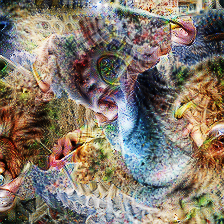

finetuned model


100%|██████████| 512/512 [00:15<00:00, 33.63it/s]



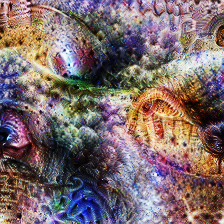

In [ ]:
from lucent.optvis import render, param, transform, objectives

layer = "layer4_2_conv3"
channel = 10
obj = objectives.channel(layer, channel)

param_image = lambda: param.image(224, fft=True, decorrelate=True)

all_transforms = [
    transform.pad(16),
    transform.jitter(8),
    transform.random_scale([n/100. for n in range(80, 120)]),
    transform.random_rotate(list(range(-10,10)) + list(range(-5,5)) + 10*list(range(-2,2))),
    transform.jitter(2),
]

print("base model")
_ = render.render_vis(base_model, obj, param_image, transforms=all_transforms, show_inline=True)


print("finetuned model")
_ = render.render_vis(finetuned_model, obj, param_image, transforms=all_transforms, show_inline=True)

In [ ]:
def compare_models_inline(base_model, finetuned_model, layer_name, channel_indices, image_size=224):
    for channel in channel_indices:
        print(f"Visualizing layer: {layer_name}, channel: {channel}")

        obj = objectives.channel(layer_name, channel)

        # Base model
        base_vis = render.render_vis(
            base_model, obj, show_inline=False, fixed_image_size=image_size
        )[0]
        base_img = np.squeeze(base_vis)

        # Finetuned model
        fine_vis = render.render_vis(
            finetuned_model, obj, show_inline=False, fixed_image_size=image_size
        )[0]
        fine_img = np.squeeze(fine_vis)

        # Plotting
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow(base_img)
        axs[0].set_title("Base Model")
        axs[0].axis("off")

        axs[1].imshow(fine_img)
        axs[1].set_title("Finetuned Model")
        axs[1].axis("off")

        plt.suptitle(f"Layer: {layer_name}, Channel: {channel}")
        plt.tight_layout()
        plt.show()

In [ ]:
print(base_model.layer2[3].conv3.out_channels)

512


Visualizing layer: layer4_2_conv3, channel: 0


100%|██████████| 512/512 [00:13<00:00, 36.73it/s]


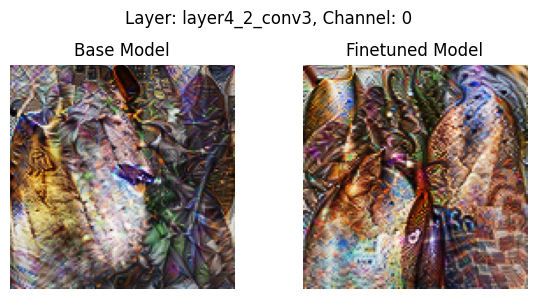

Visualizing layer: layer4_2_conv3, channel: 42


100%|██████████| 512/512 [00:14<00:00, 36.01it/s]


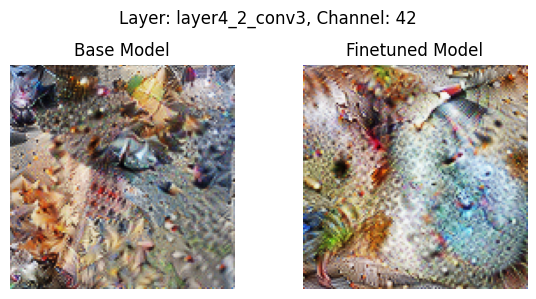

Visualizing layer: layer4_2_conv3, channel: 511


100%|██████████| 512/512 [00:14<00:00, 34.18it/s]


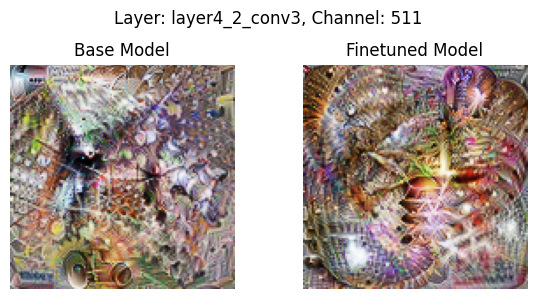

In [ ]:
channel_indices = [0, 42, 511]
compare_models_inline(base_model, finetuned_model, "layer4_2_conv3", channel_indices)

Visualizing layer: layer2_3_conv3, channel: 0


100%|██████████| 512/512 [00:11<00:00, 44.11it/s]


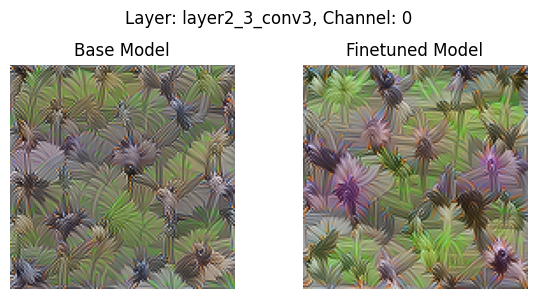

Visualizing layer: layer2_3_conv3, channel: 42


100%|██████████| 512/512 [00:11<00:00, 43.03it/s]


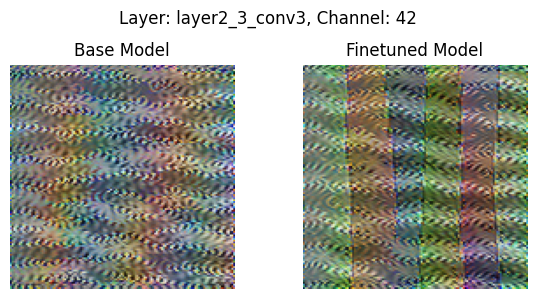

Visualizing layer: layer2_3_conv3, channel: 511


100%|██████████| 512/512 [00:11<00:00, 43.43it/s]


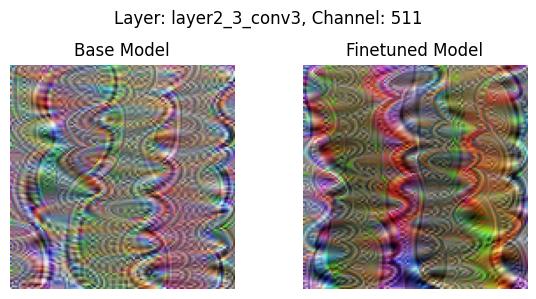

In [ ]:
# Should be very similar because layer2 is not finetuned
channel_indices = [0, 42, 511]
compare_models_inline(base_model, finetuned_model, "layer2_3_conv3", channel_indices)